In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,classification_report,confusion_matrix,roc_auc_score
from sklearn.preprocessing import StandardScaler

In [2]:
# Load Dataset
df=pd.read_csv("Datasets/NCRB_Table_1A.1.csv")

In [3]:
# Rename columns for use
df.columns=['SL_No','State','Crimes_2020','Crimes_2021','Crimes_2022','Population_lakhs','Crime_Rate_2022','Chargesheeting_Rate']

In [4]:
df=df[~df['State'].str.contains('Total',na=False)].reset_index(drop=True)

In [5]:
df.head()

,SL_No,State,Crimes_2020,Crimes_2021,Crimes_2022,Population_lakhs,Crime_Rate_2022,Chargesheeting_Rate
0,1,Andhra Pradesh,188997,179611,158547,530.3,299.0,86.5
1,2,Arunachal Pradesh,2244,2626,2308,15.5,148.8,47.2
2,3,Assam,111558,119883,59315,354.9,167.1,32.6
3,4,Bihar,194698,186006,211079,1255.3,168.1,75.4
4,5,Chhattisgarh,65216,70519,73822,299.5,246.5,80.4


In [6]:
df.tail()

,SL_No,State,Crimes_2020,Crimes_2021,Crimes_2022,Population_lakhs,Crime_Rate_2022,Chargesheeting_Rate
31,32,Delhi,249192,291904,300429,211.0,1424.1,30.2
32,33,Jammu and Kashmir,25233,27447,25915,135.4,191.4,77.1
33,34,Ladakh,387,519,439,3.0,146.8,82.4
34,35,Lakshadweep,107,89,64,0.7,92.8,73.5
35,36,Puducherry,6725,3851,3237,16.2,199.7,91.3


### Basic Info

In [7]:
# Data info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   SL_No                36 non-null     object 
 1   State                36 non-null     object 
 2   Crimes_2020          36 non-null     int64  
 3   Crimes_2021          36 non-null     int64  
 4   Crimes_2022          36 non-null     int64  
 5   Population_lakhs     36 non-null     float64
 6   Crime_Rate_2022      36 non-null     float64
 7   Chargesheeting_Rate  36 non-null     float64
dtypes: float64(3), int64(3), object(2)
memory usage: 2.4+ KB


In [8]:
# Data Summary
df.describe()

,Crimes_2020,Crimes_2021,Crimes_2022,Population_lakhs,Crime_Rate_2022,Chargesheeting_Rate
count,36.000000,36.000000,36.000000,36.000000,36.000000,36.000000
mean,118176.555556,101760.000000,98927.194444,383.261111,241.252778,67.991667
std,176923.509449,118652.699382,117142.926576,497.400312,235.523156,20.334367
min,107.000000,89.000000,64.000000,0.700000,45.400000,10.400000
25%,2524.500000,2479.750000,2934.250000,16.075000,138.300000,57.375000
50%,50451.500000,47069.000000,46232.000000,255.250000,175.300000,75.350000
75%,165794.250000,163026.250000,157014.000000,566.250000,292.075000,82.425000
max,891700.000000,367218.000000,401787.000000,2340.900000,1424.100000,96.000000


### Correlation Heatmap

In [9]:
numeric_df=df[['Crimes_2020','Crimes_2021','Crimes_2022','Population_lakhs','Crime_Rate_2022','Chargesheeting_Rate']]

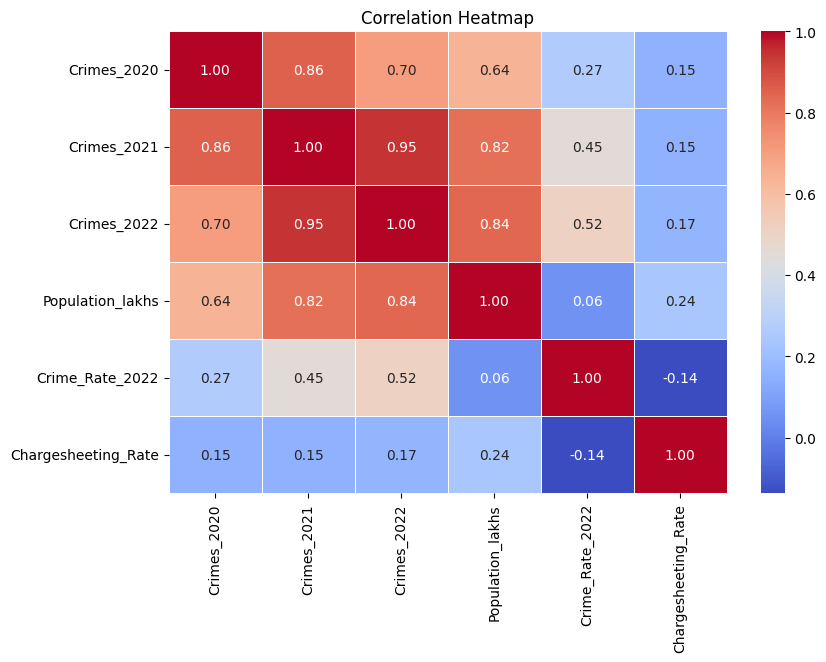

In [10]:
plt.figure(figsize=(9,6))
sns.heatmap(numeric_df.corr(),annot=True,fmt='.2f',cmap='coolwarm',linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### Crime Rate by State Bar Chart

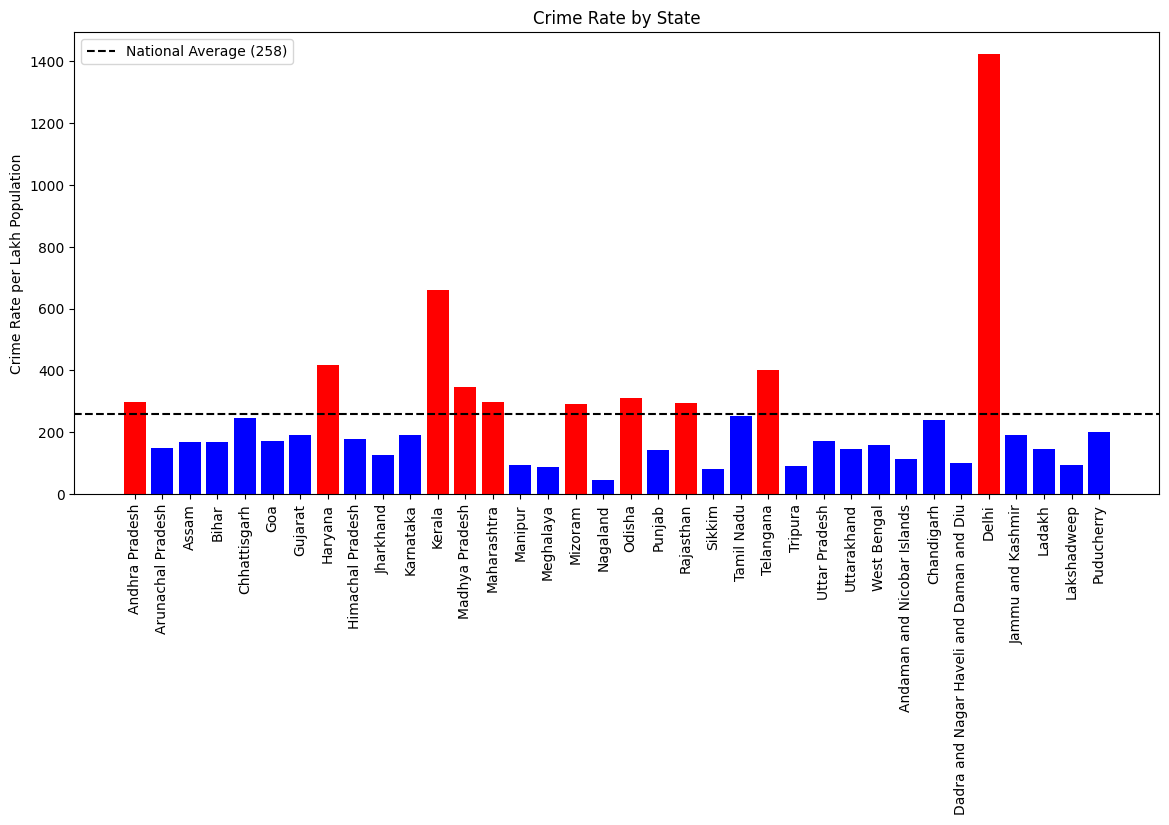

In [11]:
plt.figure(figsize=(14,6))
colors=['red' if x > 258 else 'blue' for x in df['Crime_Rate_2022']]
plt.bar(df['State'],df['Crime_Rate_2022'],color=colors)
plt.axhline(y=258,color='black',linestyle='--',label='National Average (258)')
plt.xticks(rotation=90)
plt.title("Crime Rate by State")
plt.ylabel('Crime Rate per Lakh Population')
plt.legend()
plt.show()

### Part - 1 Multiple Linear Regression

In [12]:
# Define independent value and dependent value
x=df[['Crimes_2022','Population_lakhs','Chargesheeting_Rate']]
y=df['Crime_Rate_2022']

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)

In [13]:
# Fit the model
MLR=LinearRegression()
MLR.fit(x_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [14]:
from sklearn.metrics import mean_absolute_error
y_pred=MLR.predict(x_test)

MLR_r2=r2_score(y_test,y_pred)
MLR_rmse=np.sqrt(mean_squared_error(y_test,y_pred))
MLR_mae=mean_absolute_error(y_test,y_pred)

print("R2 Score for Multiple Linear Regression :",MLR_r2)
print("RMSE for Multiple Linear Regression :",MLR_rmse)
print("MAE for Multiple Linear Regression :",MLR_mae)

R2 Score for Multiple Linear Regression : 0.5403267672722218
RMSE for Multiple Linear Regression : 279.561288131703
MAE for Multiple Linear Regression : 139.95398326712532


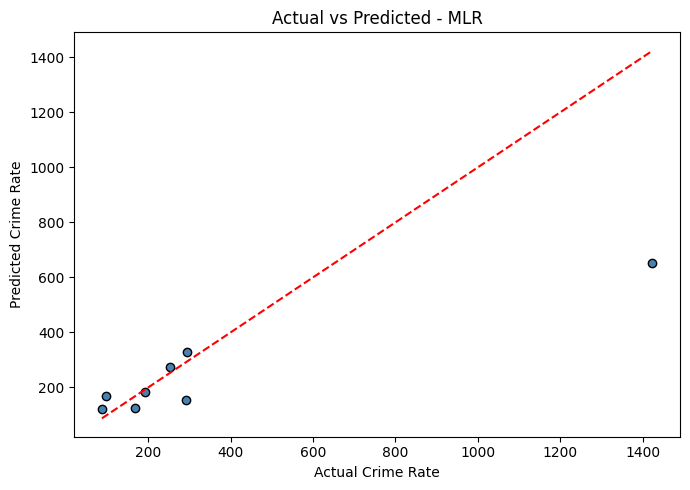

In [15]:
plt.figure(figsize=(7,5))
plt.scatter(y_test,y_pred,color='steelblue',edgecolors='black')
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.title('Actual vs Predicted - MLR')
plt.xlabel('Actual Crime Rate')
plt.ylabel('Predicted Crime Rate')
plt.tight_layout()
plt.show()

### Part -2 Logistic Regression

In [16]:
# Create Binary value for Logistic Regression

df['High_Crime']=df['Crime_Rate_2022'].apply(lambda x: 1 if x>258 else 0)
print(df['High_Crime'].value_counts())

High_Crime
0    26
1    10
Name: count, dtype: int64


In [17]:
# Define independent value and dependent value
x2=df[['Crimes_2022','Population_lakhs','Chargesheeting_Rate']]
y2=df['High_Crime']

sc=StandardScaler()
x2=sc.fit_transform(x2)

In [18]:
# Splitting Data for testing and training
x2_train,x2_test,y2_train,y2_test=train_test_split(x2,y2,test_size=0.2,random_state=0)

In [19]:
# Fit into model
from sklearn.linear_model import LogisticRegression
LR=LogisticRegression()
LR.fit(x2_train,y2_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [20]:
y2_pred=LR.predict(x2_test)

LR_r2=r2_score(y2_test,y2_pred)

print("R2 Score for Logistic Regression :",LR_r2)
print(classification_report(y2_test,y2_pred))

R2 Score for Logistic Regression : 0.4666666666666667
              precision    recall  f1-score   support

           0       0.83      1.00      0.91         5
           1       1.00      0.67      0.80         3

    accuracy                           0.88         8
   macro avg       0.92      0.83      0.85         8
weighted avg       0.90      0.88      0.87         8



### Confusion matrix for Logistic Regression

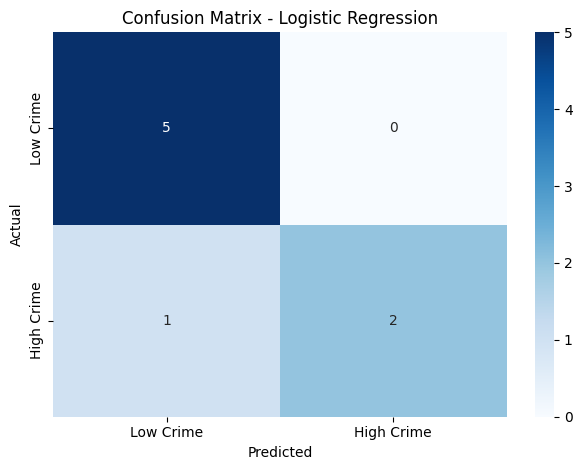

In [21]:
cm=confusion_matrix(y2_test,y2_pred)
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',
            xticklabels=['Low Crime','High Crime'],
            yticklabels=['Low Crime','High Crime'])
plt.title('Confusion Matrix - Logistic Regression')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

### Model Comparison

In [22]:
results=pd.DataFrame({
    "Model":["Multiple Linear Regression","Logistic Regression"],
    "R2 Score":[MLR_r2,LR_r2]
})
print(results)

                        Model  R2 Score
0  Multiple Linear Regression  0.540327
1         Logistic Regression  0.466667


### Sample Output

In [23]:
# Predict Crime Rate for a new value
new_data=pd.DataFrame({
    'Crimes_2022':[150000],
    'Population_lakhs':[500],
    'Chargesheeting_Rate':[75]
})

mlr_pred=MLR.predict(new_data)
print("Predicted Crime Rate (MLR) :",round(mlr_pred[0],2))

Predicted Crime Rate (MLR) : 284.06


In [24]:
# Predict High/Low Crime (Logistic)
new_scaled=sc.transform(new_data)
log_pred=LR.predict(new_scaled)
log_prob=LR.predict_proba(new_scaled)[:,1]

print("Predicted Class (Logistic) :","High Crime" if log_pred[0]==1 else "Low Crime")
print("Probability of High Crime :",round(log_prob[0],4))

Predicted Class (Logistic) : Low Crime
Probability of High Crime : 0.3537


## Time series Analysis 

In [28]:
State_crimes = df[['State','Crimes_2020','Crimes_2021','Crimes_2022']]
State_crimes.head()

,State,Crimes_2020,Crimes_2021,Crimes_2022
0,Andhra Pradesh,188997,179611,158547
1,Arunachal Pradesh,2244,2626,2308
2,Assam,111558,119883,59315
3,Bihar,194698,186006,211079
4,Chhattisgarh,65216,70519,73822


### Predict 2023 to 2025 for Each State

In [ ]:
years = np.array([2020,2021,2022]).reshape(-1,1)
future_years=np.array([2023,2024,2025]).reshape(-1,1)
state_pred=[]

